# CoexpressDeconvolve
#### Automated Visium Standard Definition Spatial Transcriptomics data deconvolution

In [1]:
# %pip install h5py tqdm

In [1]:
import codeconv
import os

In [2]:
visium_path = "." 
output_folder = "."
config_path = "codeconv_config.json"

Step 1: Checking data format in ....
   > Found H5 file: ./filtered_feature_bc_matrix.h5. Loading...

LIBRARY DEPTH QC
Median UMI per Spot: 13532
Mean UMI per Spot:   23097
1th Percentile:      1253


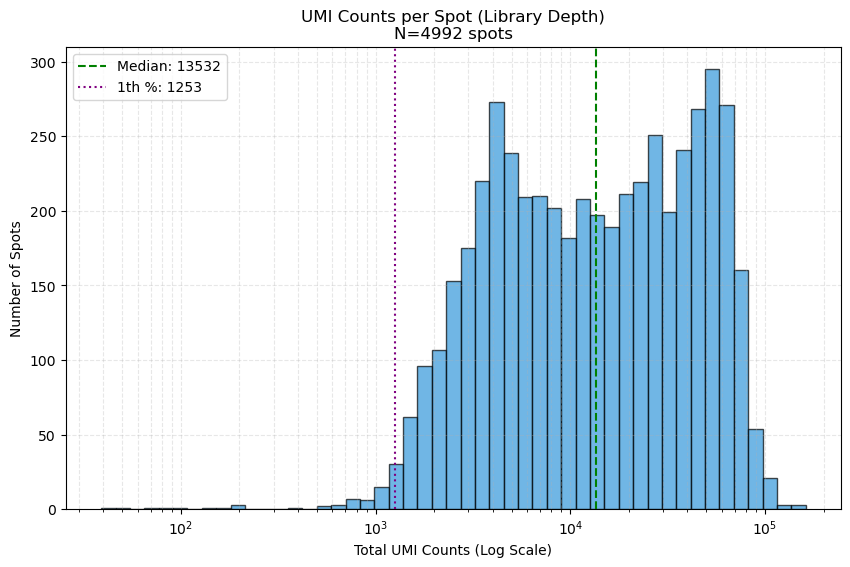

Step 1 took 0.594131 seconds


In [3]:
# STEP 1: LOAD
raw_counts, gene_names, barcodes, coords, total_umi, scales = codeconv.step1_acquisition_and_anchoring(visium_path)

Step 2: Loading Single Cell Standard from codeconv_config.json...
Step 2: Using 13 HK genes for calibration.


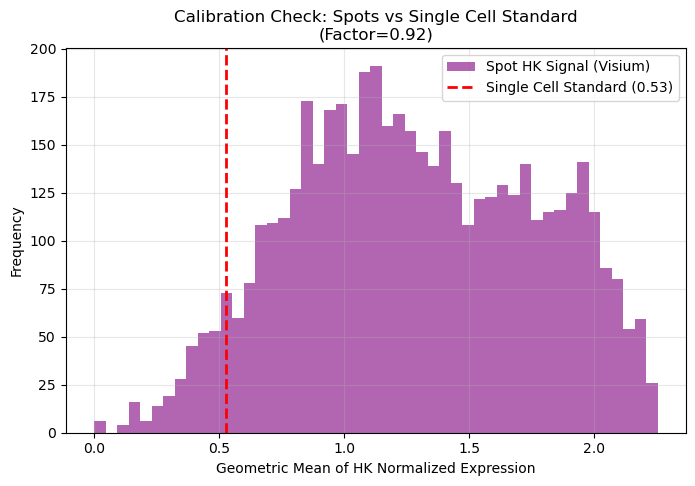

   > Single Cell Standard is: 0.53

FILTERING REPORT
Total Empty Spots (0 cells): 70 / 4992 (1.4%)
Among them are those with low UMI content: 27


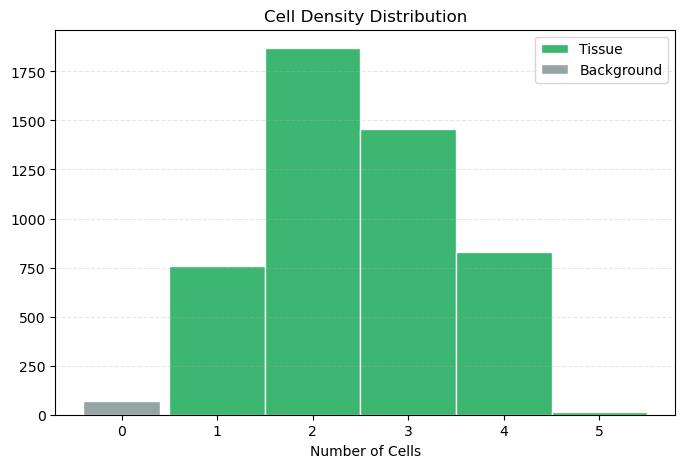

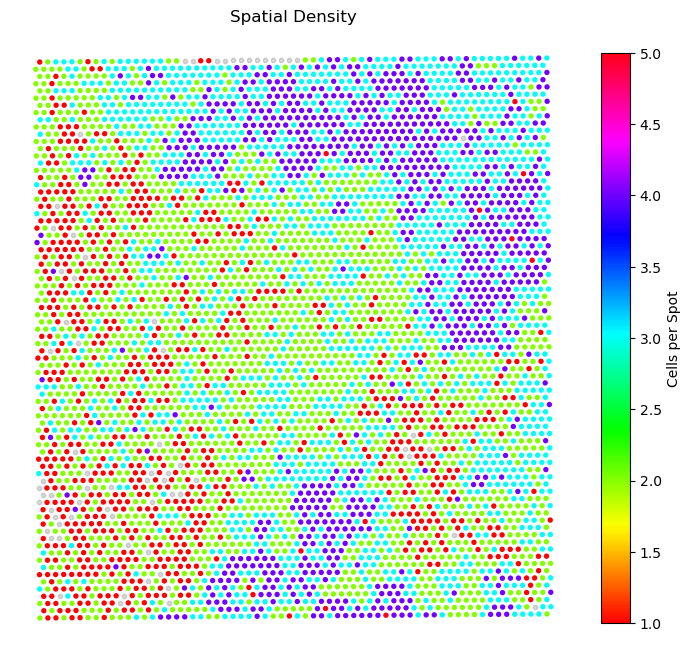


The number of cells on the Visium slide is 12240.
Step 2 took 0.283157 seconds


In [4]:
# STEP 2: DENSITY
n_cells_per_spot, engine_params = codeconv.step2_estimate_cell_density(
    raw_counts, 
    gene_names, 
    total_umi, 
    coords, 
    config_path,
    min_umi=900, 
    anchor_mean_factor=0.92, # adjust this factor to align the red line with the first non-zero peak on the graph
    colormap='hsv'
)

Step 3: Filtering transcriptome (Species: hs)...
   - Removed 54 noise genes.
   - Remaining feature space: 18031 genes.
Step 3: Selecting top 2000 HVGs for Model Training...


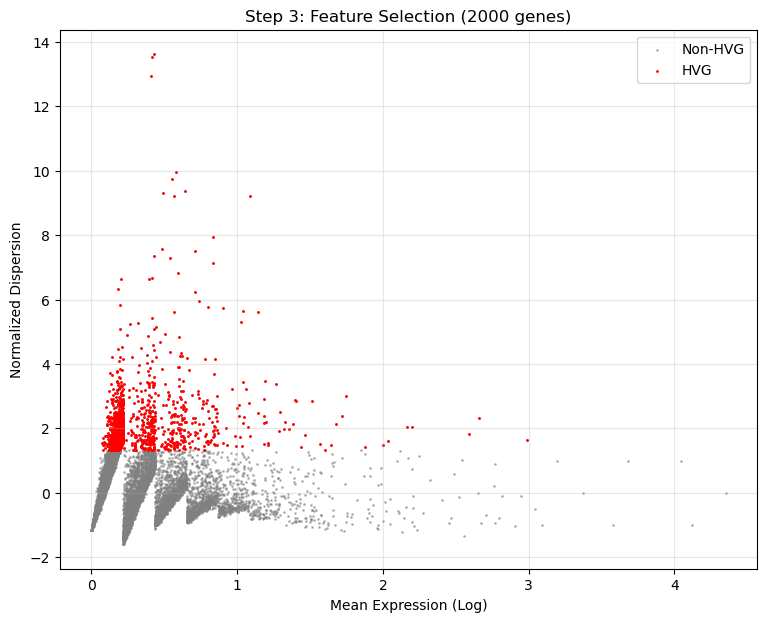

Step 3 Complete. Training set shape: (4992, 2000)
Step 3 took 1.311482 seconds


In [5]:
# STEP 3: Cleanup & Select HVGs
counts_clean, genes_clean, hvg_data, hvg_names = codeconv.step3_feature_selection(
    raw_counts, gene_names,
    species='hs', # 'hs' / 'mm'
    n_hvg=2000
)

Step 4: Constructing Gene Manifold for 18031 genes...
   - Preprocessing: Log-transformation and Scaling...
   - Decomposition: FastICA (30 components)...
   - Topology: UMAP Projection (Metric: Cosine)...


/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


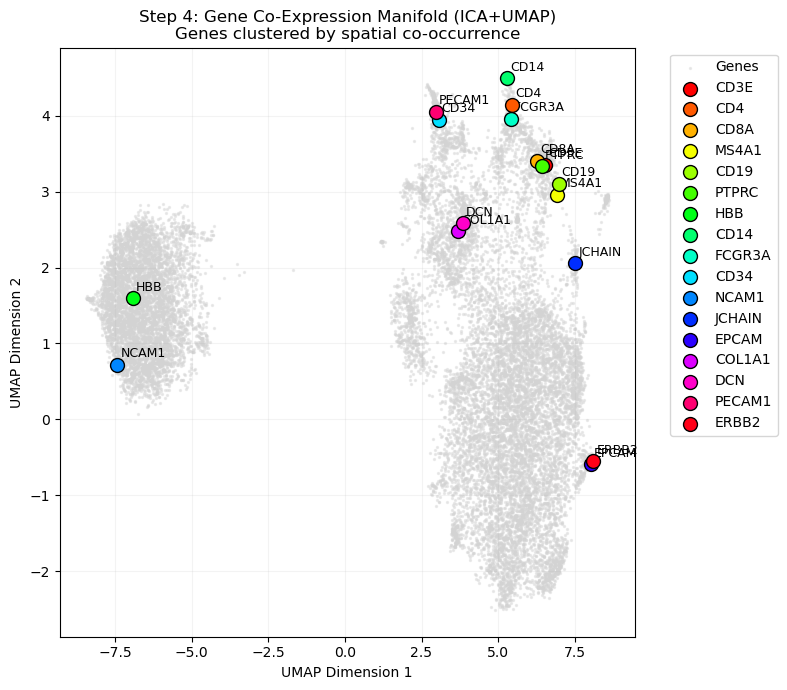

Step 4 took 109.404826 seconds


In [6]:
# STEP 4: Construct Gene Coexpression Manifold
embedding, reducer = codeconv.step4_gene_manifold(
    counts_clean, genes_clean, n_components = 30
)

Step 5: K-Sweep (Range: 3-20, Sampling: 100%)...


Training LDA models:   0%|          | 0/18 [00:00<?, ?it/s]

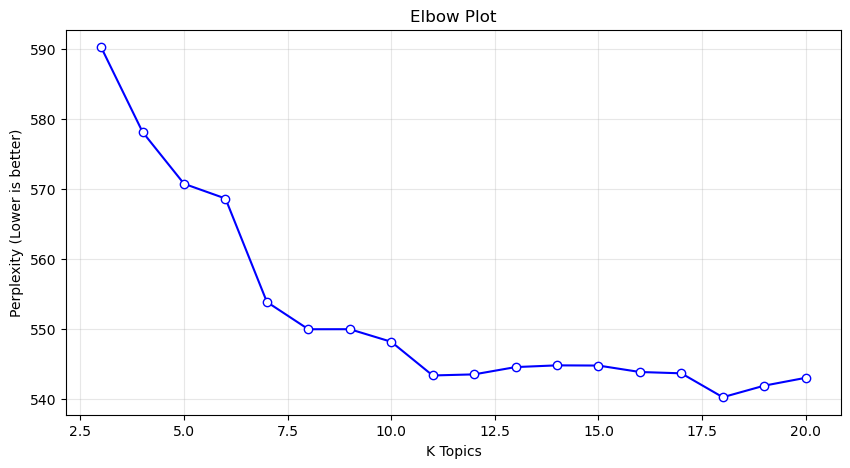

Step 5 took 214.425279 seconds


{3: np.float64(590.2830046603871),
 4: np.float64(578.1582138978874),
 5: np.float64(570.759133017652),
 6: np.float64(568.650167102288),
 7: np.float64(553.858143732602),
 8: np.float64(549.9599612196779),
 9: np.float64(549.9661202192186),
 10: np.float64(548.1680929614486),
 11: np.float64(543.3515993320467),
 12: np.float64(543.5067697255456),
 13: np.float64(544.5492889554563),
 14: np.float64(544.796922654114),
 15: np.float64(544.7682727678213),
 16: np.float64(543.8473033126651),
 17: np.float64(543.657578493157),
 18: np.float64(540.2406278901095),
 19: np.float64(541.8939873184083),
 20: np.float64(543.0158817423695)}

In [7]:
# STEP 5: K optimization

codeconv.step5_ksweep(hvg_data, min_k=3, max_k=20, step=1, subsample_frac=1,
                      doc_topic_prior=0.1,topic_word_prior=0.01)

In [8]:
# STEP 6: Final LDA Model & Manifold-Guided Projection

SELECTED_K = 11 

print(f"Starting Step 6 with K={SELECTED_K}...")

theta, beta_final, qc_df = codeconv.step6_final_deconvolution(
    hvg_data,      
    counts_clean,  
    genes_clean,
    hvg_names,
    n_topics=SELECTED_K,
    embedding=embedding,
    n_iters=30,
    k_neighbors=3,       # Nearest neighbors on the UMAP map
    min_sim=0.05,        # Minimum cosine expression similarity threshold
    doc_topic_prior=0.1,
    topic_word_prior=0.01
)

print("Top markers per topic:")
display(qc_df)

Starting Step 6 with K=11...
Step 6: Training Final LDA Model with chosen K=11...
iteration: 1 of max_iter: 30
iteration: 2 of max_iter: 30
iteration: 3 of max_iter: 30
iteration: 4 of max_iter: 30
iteration: 5 of max_iter: 30
iteration: 6 of max_iter: 30
iteration: 7 of max_iter: 30
iteration: 8 of max_iter: 30
iteration: 9 of max_iter: 30
iteration: 10 of max_iter: 30
iteration: 11 of max_iter: 30
iteration: 12 of max_iter: 30
iteration: 13 of max_iter: 30
iteration: 14 of max_iter: 30
iteration: 15 of max_iter: 30
iteration: 16 of max_iter: 30
iteration: 17 of max_iter: 30
iteration: 18 of max_iter: 30
iteration: 19 of max_iter: 30
iteration: 20 of max_iter: 30
iteration: 21 of max_iter: 30
iteration: 22 of max_iter: 30
iteration: 23 of max_iter: 30
iteration: 24 of max_iter: 30
iteration: 25 of max_iter: 30
iteration: 26 of max_iter: 30
iteration: 27 of max_iter: 30
iteration: 28 of max_iter: 30
iteration: 29 of max_iter: 30
iteration: 30 of max_iter: 30
Step 6: Projecting latent t

,Topic_0,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5,Topic_6,Topic_7,Topic_8,Topic_9,Topic_10
0,ADGRL2,LRRC31,IGHA1,CPB1,TNN,FAM177B,SYTL4,YBX2,ADIPOQ,CCL19,ARL4A
1,LY6H,PCLO,HSPA13,TSPAN6,SHC4,MUCL1,GREB1,IPO4,PLIN4,IGHG3,FDCSP
2,CDH5,TMEM92,IGKC,TINCR,MMP11,HHIPL2,TFF1,FMO5,ADH1B,PARP11,SPP1
3,NR5A2,GRB14,TXNDC11,MVD,RAB38,SYBU,NXNL2,ITGA2B,CNTFR,CCR7,IL1RN
4,EBF3,EREG,ITM2C,MEAK7,SOSTDC1,ABHD4,TPD52L1,AKAP5,ACVR1C,BTG1,AQP9
5,SCN4A,MUC2,PIM2,ABHD17C,COL11A1,RCE1,C5AR2,SGPP2,GPD1,FLT3,SLC11A1
6,SHROOM4,UGT2B4,IGHG1,NECTIN2,COL10A1,SMIM31,ESR1,TMEM97,ARHGEF6,PLAC8,CTSL
7,SLC35G2,CLEC3A,DERL3,LENG9,OLFM2,C8orf82,GFRA1,CLGN,FHL1,ANXA2R,CCL18
8,GNB1L,NPW,UBE2J1,TRH,GPR87,MAPK10,EMP2,PIMREG,FABP4,TBC1D10C,LTF
9,DLL4,SAMD13,TXNDC5,UGT2B11,COL9A2,LZTS3,MSMB,TRERF1,CIDEC,SCIMP,KCP


In [9]:
# STEP 7: Generate deconvolved in silico single cells

final_matrix, cell_metadata = codeconv.step7_sampling_engine(
    counts_clean, n_cells_per_spot, theta, beta_final, engine_params
)

Step 7: initializing Sampling Engine...


Generating Single Cells:   0%|          | 0/4992 [00:00<?, ?spot/s]


   > Generated 12240 single cells total.
Step 7 Complete.
Step 7 took 196.402554 seconds


In [10]:
# STEP 8: Place the deconvolved in silico single cells back on slide
final_bcs, final_coords = codeconv.step8_geometry_and_placement(
    cell_metadata, coords, barcodes, scales
)

# STEP 9:10X file format export (h5 + spatial)
codeconv.step9_export_results(
    output_folder, final_matrix, genes_clean, final_bcs, final_coords, 
    os.path.join(visium_path, "spatial")
)

   > Calculating Fibonacci shell positions...
Step 8 Complete.
Step 8 took 0.039877 seconds
Step 9: Exporting data to ./deconvolved ...
   > Writing HDF5 matrix to ./deconvolved/filtered_feature_bc_matrix.h5...
Step 9 Complete. Output is ready for Seurat::Load10X_Spatial().
Step 9 took 0.278527 seconds
